In [1]:
import sys, os
import argparse
import awkward as ak
from datetime import datetime
import io
from matplotlib import pyplot as plt
import numpy as np
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool

from gnn_encoder import collate_fn_gnn, GNNEncoder
from gnn_trafo_helper import normalize, denormalize, train_model, evaluate_model

In [2]:
DATA_PATH = "../data/IceCube/"  # path to the data

In [3]:
# Load the dataset
train_dataset = ak.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = ak.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = ak.from_parquet(os.path.join(DATA_PATH, "test.pq"))

In [4]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.\n")

print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}\n")

# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.

The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']

The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}


In [5]:
# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}\n")

# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748

The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]


In [6]:
# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")

print('\n')
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x = -2.5, y = -2.5
Hit 2: time = 8.996675814194964, x = 2.5, y = -2.5
Hit 3: time = 12.021784213609394, x = 2.5, y = -2.5
Hit 4: time = 12.923289636173713, x = 2.5, y = -2.5
Hit 5: time = 25.1516276582378, x = -2.5, y = -0.8333333333333333
Hit 6: time = 15.286326473533162, x = 0.8333333333333335, y = -0.8333333333333333
Hit 7: time = 15.14788039212255, x = 2.5, y = -0.8333333333333333
Hit 8: time = 16.565114961505415, x = -0.8333333333333333, y = 0.8333333333333335
Hit 9: time = 19.47621700139486, x = -0.8333333333333333, y = 0.8333333333333335
Hit 10: time = 16.912010076540938, x = 2.5, y = 2.5
Hit 11: time = 19.57845737402364, x = 2.5, y = 2.5


The first event of the training dataset has the following hit times: [14.5, 17.1, 9, 12, 12.9, 25.2, 15.3, 15.1, 16.6, 19.5, 16.9, 19.6]
The first event of the training dataset has t

In [7]:
# Normalize data and labels
# working with Awkward arrays is a bit tricky because the ['data'] field can't be assigned in-place,
# so we need to extract the time, x, and y coordinates, normalize them separately,
# and then concatenate them back together.

train_norm, norm_stats = normalize(train_dataset)
val_norm, _ = normalize(val_dataset)
test_norm, _ = normalize(test_dataset)

In [8]:
# Create the DataLoader for training, validation, and test datasets
# Important: We use the custom collate function to preprocess the data for GNN (see the description of the collate function for details)

batch_size = 32
train_loader = DataLoader(train_norm, batch_size = batch_size, shuffle = True, collate_fn = collate_fn_gnn)
val_loader = DataLoader(val_norm, batch_size = batch_size, shuffle = False, collate_fn = collate_fn_gnn)
test_loader = DataLoader(test_norm, batch_size = batch_size, shuffle = False, collate_fn = collate_fn_gnn)

In [9]:
# Defining the device pytorch in running on
device = (
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

# Loss function
class CustomLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        return torch.mean((pred - target)**2)

In [10]:
# Training
num_epochs = 100
learning_rate = 0.002
patience = 10
k_values = [3, 5, 8, 12, 20] # Testing for different amount of nearest neighbors

loss_function = CustomLoss()

#Initializing a directory for saving the results
results = {}
for k in k_values:
    print('-------------------')
    print(f'k = {k}')
    print('-------------------')
    model = GNNEncoder(k=k)
    train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device)

    results[k] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_model': best_model
    }

-------------------
k = 3
-------------------
Epoch [1/100], Step [310/313], Loss: 0.1687
Epoch [1/100], Train Loss: 0.3076, Val Loss: 0.1677, Time: 9.52 seconds
Epoch [2/100], Step [310/313], Loss: 0.2192
Epoch [2/100], Train Loss: 0.1497, Val Loss: 0.1490, Time: 9.56 seconds
Epoch [3/100], Step [310/313], Loss: 0.0861
Epoch [3/100], Train Loss: 0.1292, Val Loss: 0.1291, Time: 9.86 seconds
Epoch [4/100], Step [310/313], Loss: 0.1112
Epoch [4/100], Train Loss: 0.1240, Val Loss: 0.1244, Time: 9.61 seconds
Epoch [5/100], Step [310/313], Loss: 0.0768
Epoch [5/100], Train Loss: 0.1132, Val Loss: 0.1329, Time: 10.06 seconds
Epoch [6/100], Step [310/313], Loss: 0.1075
Epoch [6/100], Train Loss: 0.1107, Val Loss: 0.1097, Time: 10.07 seconds
Epoch [7/100], Step [310/313], Loss: 0.0983
Epoch [7/100], Train Loss: 0.1033, Val Loss: 0.1137, Time: 9.82 seconds
Epoch [8/100], Step [310/313], Loss: 0.0767
Epoch [8/100], Train Loss: 0.1017, Val Loss: 0.1156, Time: 9.82 seconds
Epoch [9/100], Step [310

Evaluating model on the test dataset...
Final Test Loss: 0.1928
Best k-value: k =  8


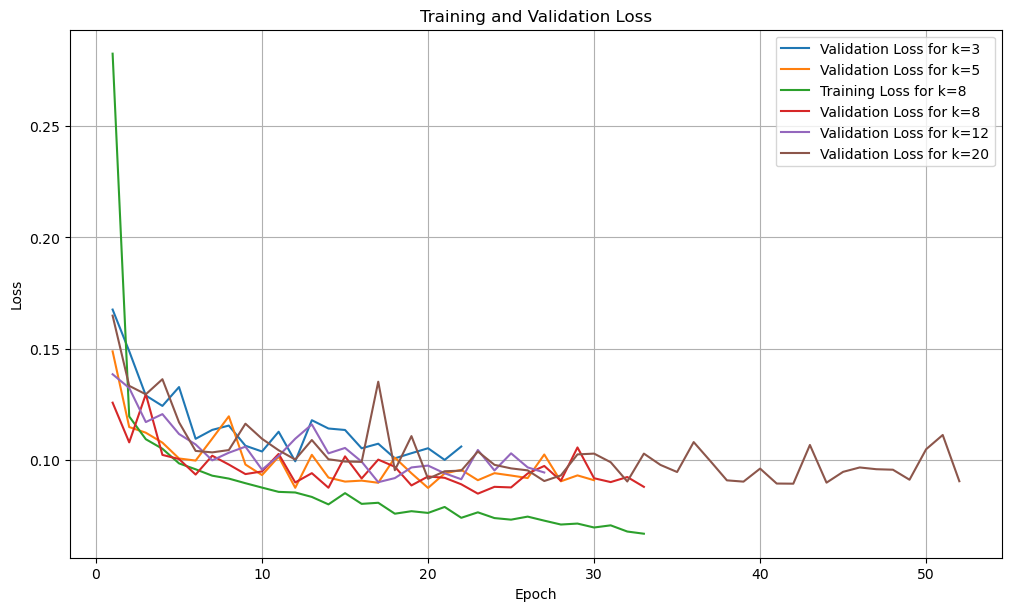

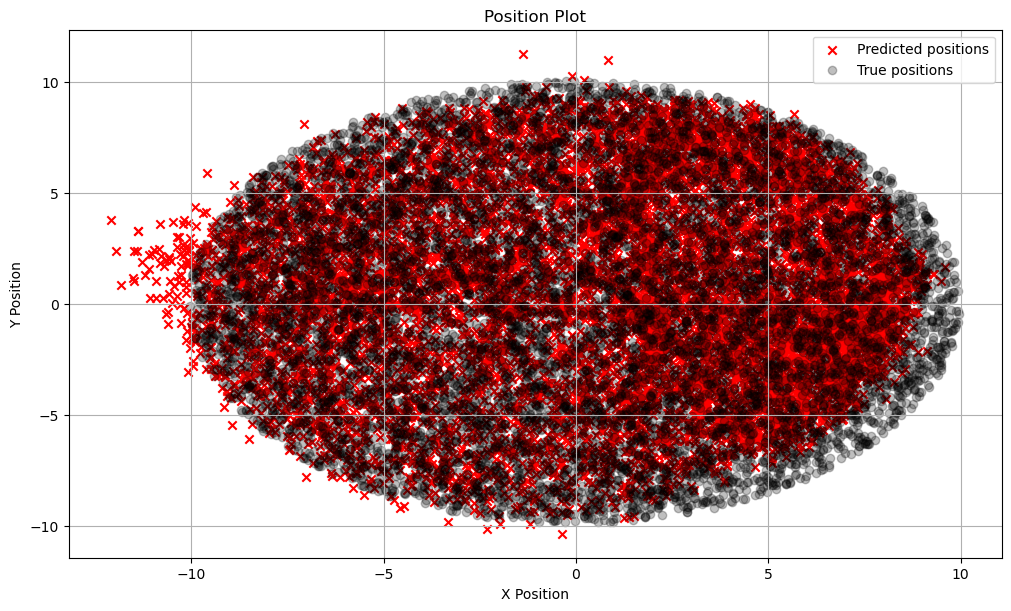

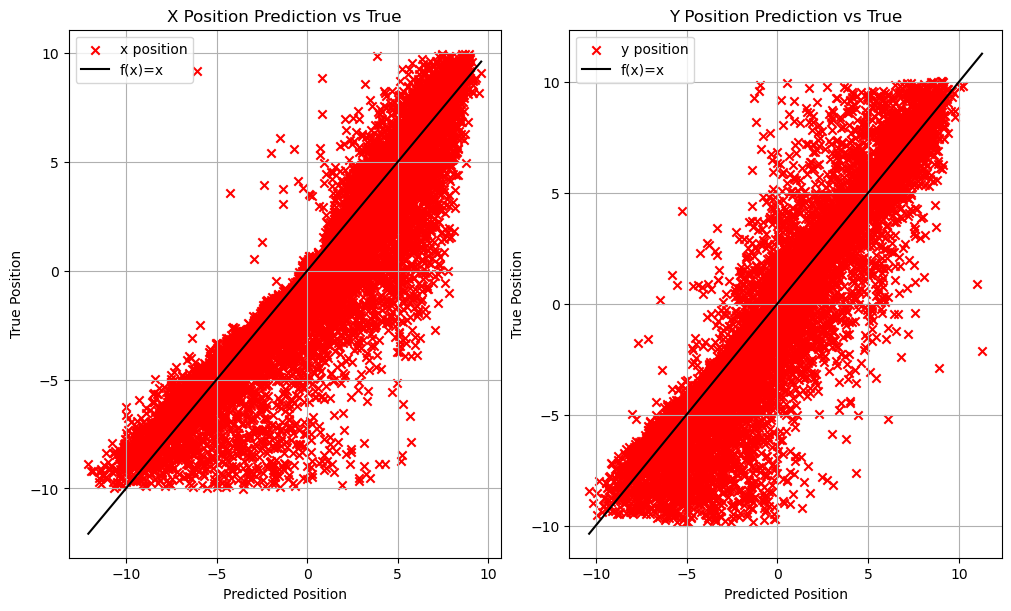

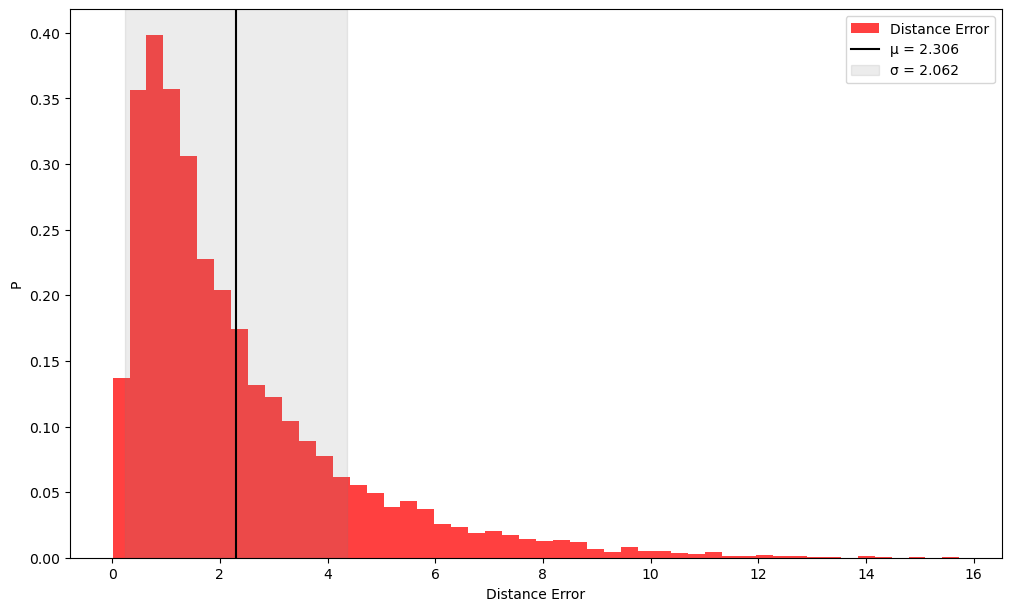

In [16]:
# Loading the best k value and the best model
best_k = min(results, key=lambda k: min(results[k]['val_losses']))
model.load_state_dict(results[best_k]['best_model'])  # Load the best model
# save the best model to the "models" directory
if not os.path.exists('models'):
    os.makedirs('models')
torch.save(results[best_k]['best_model'], f'models/GNNEncoder_best_k={best_k}.pth')
model.to(device)

all_predictions, all_true_labels,_,_ = evaluate_model(model, test_loader, loss_function, device)
all_predictions = denormalize(all_predictions, norm_stats)  # Denormalize predictions
all_true_labels = denormalize(all_true_labels, norm_stats)  # Denormalize true labels

print('Best k-value: k = ', best_k)
####################################
### Plotting the learning curves ###
####################################
fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')
for k in k_values:
    # Plot training and validation loss
    if k == best_k:
        ax.plot(range(1, len(results[k]['train_losses']) + 1), results[k]['train_losses'], label=f'Training Loss for k={k}')
    ax.plot(range(1, len(results[k]['val_losses']) + 1), results[k]['val_losses'], label=f'Validation Loss for k={k}')
    ax.set(
        xlabel=('Epoch'),
        ylabel=('Loss')
    )
    ax.set_title('Training and Validation Loss')
    ax.legend()
    ax.grid(True)

#############################
### Position Scatter Plot ###
#############################
fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')

ax.scatter(all_predictions[:, 0], all_predictions[:, 1], marker='x', color='red', label='Predicted positions')
ax.scatter(all_true_labels[:, 0], all_true_labels[:, 1], marker='o', color='black', alpha=0.25, label='True positions')
ax.set(
    xlabel=('X Position'),
    ylabel=('Y Position'),
    title=('Position Plot')
)
ax.legend()
ax.grid(True)

################################
### Prediction vs. True Plot ###
################################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), layout='constrained')

x_linspace = np.linspace(np.min(all_predictions[:, 0]), np.max(all_predictions[:, 0]), 1000)
y_linspace = np.linspace(np.min(all_predictions[:, 1]), np.max(all_predictions[:, 1]), 1000)

ax1.scatter(all_predictions[:, 0], all_true_labels[:, 0], marker='x', color='red', label='x position')
ax1.plot(x_linspace, x_linspace, color='black', label='f(x)=x')
ax2.scatter(all_predictions[:, 1], all_true_labels[:, 1], marker='x', color='red', label='y position')
ax2.plot(y_linspace, y_linspace, color='black', label='f(x)=x')
ax1.set(
    xlabel=('Predicted Position'),
    ylabel=('True Position'),
    title=('X Position Prediction vs True')
)
ax2.set(
    xlabel=('Predicted Position'),
    ylabel=('True Position'),
    title=('Y Position Prediction vs True')
)
ax1.legend()
ax1.grid(True)
ax2.legend()
ax2.grid(True)


#################################
### Distance Error Histogramm ###
#################################
error = np.sqrt((all_predictions[:, 0] - all_true_labels[:, 0])**2 + (all_predictions[:, 1] - all_true_labels[:, 1])**2)
mean_error = error.mean()
std_error = error.std()

fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')

ax.hist(error, bins=50, density=True, color='red', alpha=0.75, label='Distance Error')
ax.axvline(x=mean_error, color='black', label=f'µ = {mean_error:.3f}')
ax.axvspan(xmin=mean_error-std_error, xmax=mean_error+std_error, color='gray', alpha=0.15, label=f'σ = {std_error:.3f}')
ax.set(
    xlabel=('Distance Error'),
    ylabel=('P')
)
ax.legend()